In [ ]:
# SPARK session luonti
from pyspark.sql import SparkSession
from pyspark.sql.functions import to_timestamp, hour

spark = SparkSession.builder \
    .appName("US Accidents") \
    .master("local[*]") \
    .config("spark.driver.memory", "20g") \
    .getOrCreate()

spark


In [3]:
# Ladataan data
df = spark.read.csv("data/US_Accidents_March23.csv", header=True, inferSchema=True)

df = df.withColumn("Start_Time", to_timestamp("Start_Time"))
df = df.withColumn("hour", hour("Start_Time"))

df.select("Start_Time", "hour").show(5)


+-------------------+----+
|         Start_Time|hour|
+-------------------+----+
|2016-02-08 05:46:00|   5|
|2016-02-08 06:07:59|   6|
|2016-02-08 06:49:27|   6|
|2016-02-08 07:23:34|   7|
|2016-02-08 07:39:07|   7|
+-------------------+----+
only showing top 5 rows


In [4]:
df.cache()
df.count()
print("Cache ladattu!")


Cache ladattu!


In [5]:
acc_per_hour = df.groupBy("hour").count().orderBy("hour")
acc_per_hour.show(24)


+----+------+
|hour| count|
+----+------+
|   0|112378|
|   1| 97071|
|   2| 93227|
|   3| 83707|
|   4|160008|
|   5|228182|
|   6|405837|
|   7|587472|
|   8|577576|
|   9|363034|
|  10|342706|
|  11|355040|
|  12|355001|
|  13|396445|
|  14|448846|
|  15|525855|
|  16|581969|
|  17|576015|
|  18|432042|
|  19|295121|
|  20|225226|
|  21|191452|
|  22|167645|
|  23|126539|
+----+------+



  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.1 MB 15.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 16.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 10.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 9.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.4 MB/s  0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --------- ------------------------------ 2.9/12.6 MB 13.9 MB/s eta 0:00:01
   -------------------- ------------------- 6.6/12.6 MB 15.5 MB/s e

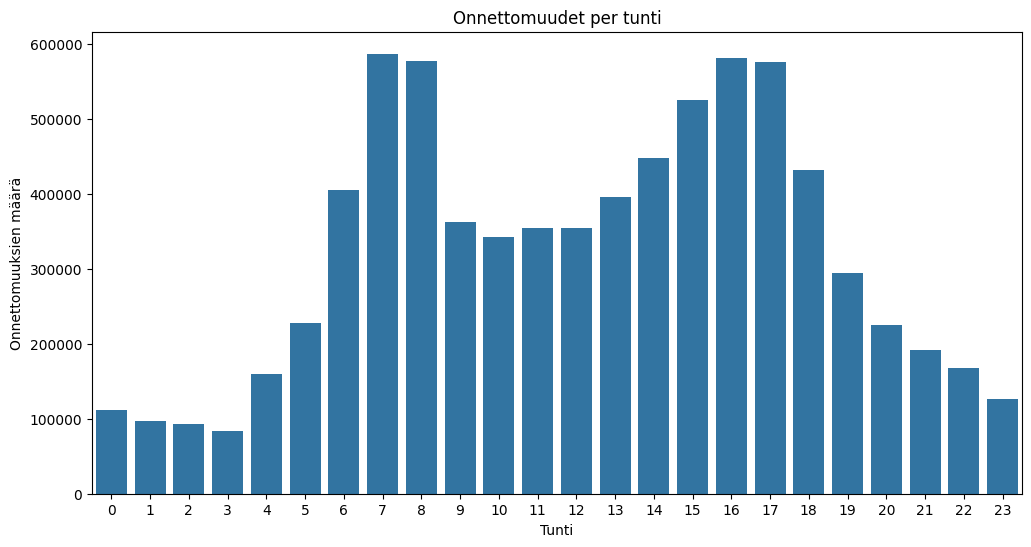

In [7]:
!pip install matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns

pdf = acc_per_hour.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=pdf, x="hour", y="count")
plt.title("Onnettomuudet per tunti")
plt.xlabel("Tunti")
plt.ylabel("Onnettomuuksien määrä")
plt.show()


In [11]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import to_timestamp, hour

spark = SparkSession.builder \
    .appName("US Accidents") \
    .master("local[*]") \
    .config("spark.driver.memory", "20g") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:3.0.1") \
    .getOrCreate()
